In [2]:
import pandas as pd
sales = pd.read_csv('../data/sales.csv')

In [3]:
## convert invoice date back to datetime
sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'])

In [4]:
## create month
sales['Month'] = sales['InvoiceDate'].dt.to_period('M')

In [5]:
## monthly sales analysis
monthly_sales = (
    sales.groupby('Month').agg
    (
        Revenue = ("Revenue","sum"),
        Orders = ("Invoice","nunique"),
        Units = ("Quantity","sum")
    )
    .reset_index()
)

In [6]:
## Calculate AOV
monthly_sales['AOV'] = (
    monthly_sales['Revenue'] / monthly_sales['Orders']
)

In [7]:
print(monthly_sales)

      Month      Revenue  Orders   Units         AOV
0   2009-12   822483.950    1839  444341  447.245215
1   2010-01   651155.112    1205  395234  540.377686
2   2010-02   551504.726    1281  391860  430.526718
3   2010-03   830915.261    1770  530314  469.443650
4   2010-04   678875.252    1512  385747  448.991569
5   2010-05   657705.500    1642  424009  400.551462
6   2010-06   749537.310    1719  413723  436.031012
7   2010-07   648810.270    1584  358590  409.602443
8   2010-08   695251.910    1511  521762  460.127009
9   2010-09   921696.991    1911  592615  482.311351
10  2010-10  1161902.220    2370  622277  490.254101
11  2010-11  1464293.142    2868  730417  510.562462
12  2010-12   437631.020     888  181708  492.827725


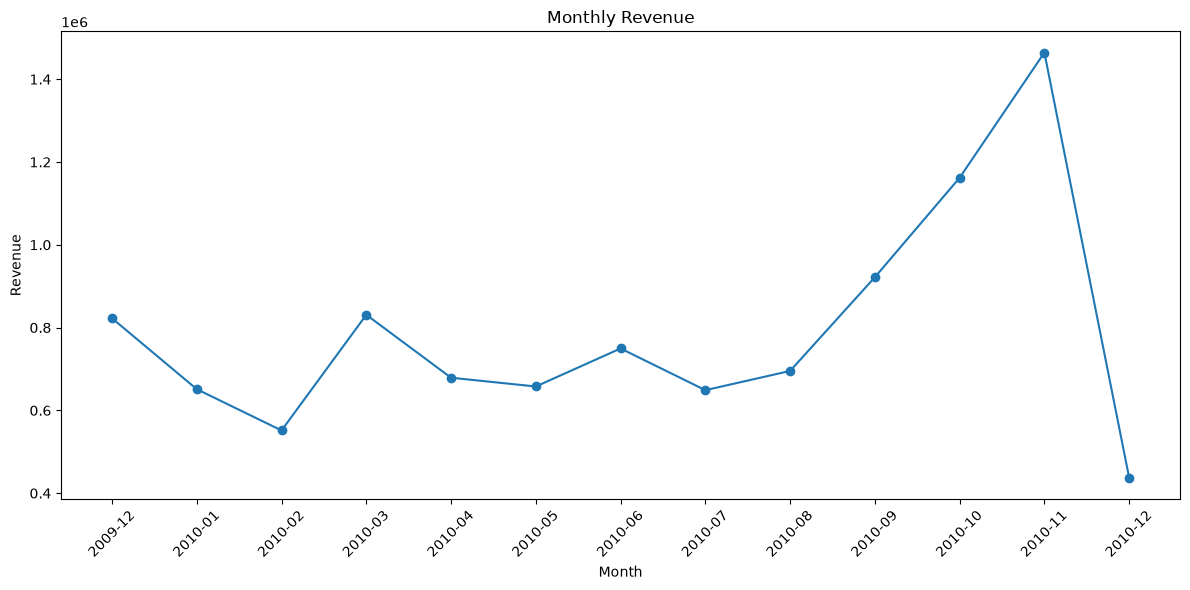

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales["Month"].astype(str),
    monthly_sales['Revenue'],
    marker='o'
)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

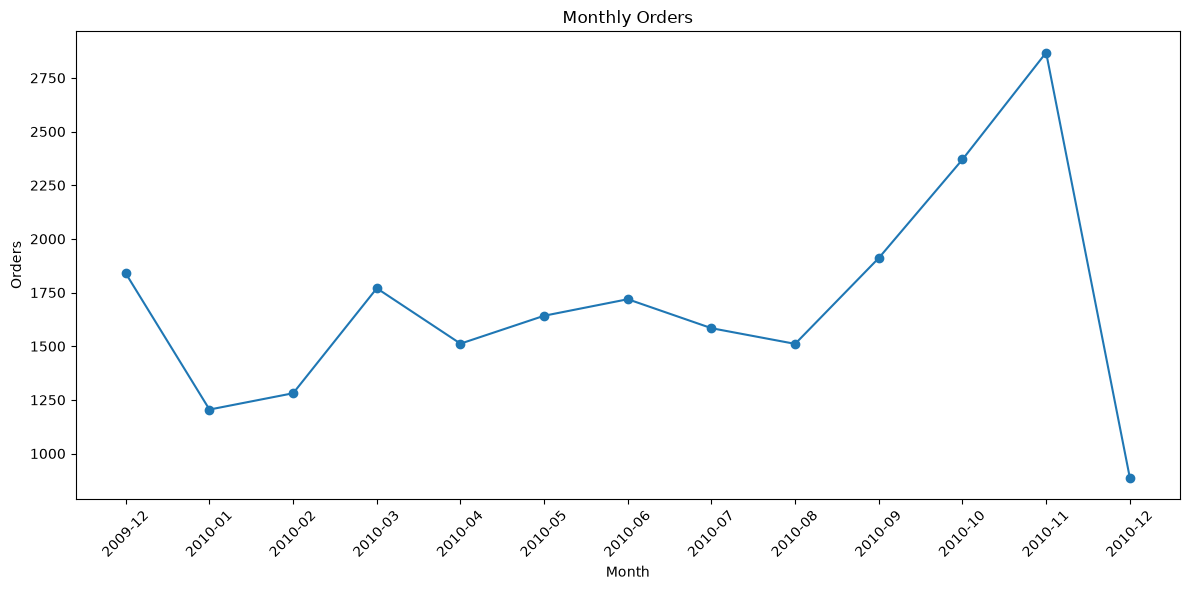

In [9]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales["Month"].astype(str),
    monthly_sales['Orders'],
    marker='o'
)
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

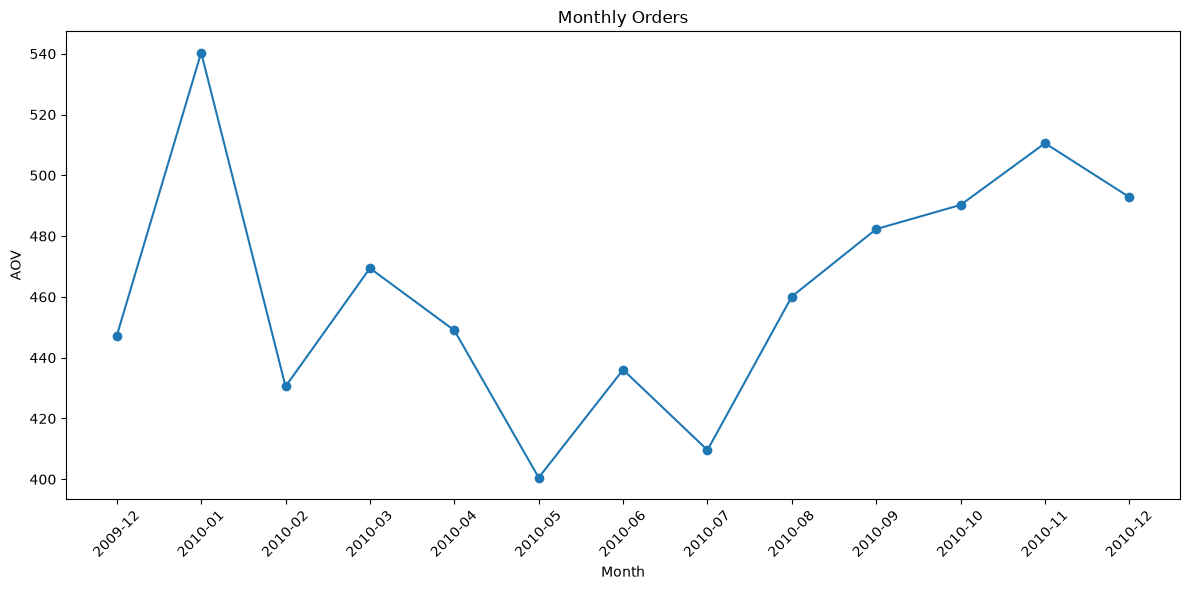

In [10]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales["Month"].astype(str),
    monthly_sales['AOV'],
    marker='o'
)
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("AOV")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
## The revenue increases because of the number of orders 
## not the average order value  

In [12]:
## revenue growth over time
monthly_sales['Revenue_Growth'] = (
    monthly_sales["Revenue"].pct_change() * 100
)
print("Monthly Sales Analysis:")
print(monthly_sales)

Monthly Sales Analysis:
      Month      Revenue  Orders   Units         AOV  Revenue_Growth
0   2009-12   822483.950    1839  444341  447.245215             NaN
1   2010-01   651155.112    1205  395234  540.377686      -20.830660
2   2010-02   551504.726    1281  391860  430.526718      -15.303633
3   2010-03   830915.261    1770  530314  469.443650       50.663307
4   2010-04   678875.252    1512  385747  448.991569      -18.297896
5   2010-05   657705.500    1642  424009  400.551462       -3.118357
6   2010-06   749537.310    1719  413723  436.031012       13.962451
7   2010-07   648810.270    1584  358590  409.602443      -13.438563
8   2010-08   695251.910    1511  521762  460.127009        7.157969
9   2010-09   921696.991    1911  592615  482.311351       32.570221
10  2010-10  1161902.220    2370  622277  490.254101       26.061193
11  2010-11  1464293.142    2868  730417  510.562462       26.025505
12  2010-12   437631.020     888  181708  492.827725      -70.113155


In [13]:
## pct_change calculate current month - previous month / previous month
# Month with highest revenue
highest_revenue_month = monthly_sales.loc[
    monthly_sales["Revenue"].idxmax()
]

# Month with lowest revenue
lowest_revenue_month = monthly_sales.loc[
    monthly_sales["Revenue"].idxmin()
]

# Highest growth
highest_growth_month = monthly_sales.loc[
    monthly_sales["Revenue_Growth"].idxmax()
]

# Lowest growth
lowest_growth_month = monthly_sales.loc[
    monthly_sales["Revenue_Growth"].idxmin()
]


print("Highest Revenue:")
print(highest_revenue_month)

print("Lowest Revenue:")
print(lowest_revenue_month)

print("Highest Revenue Growth:")
print(highest_growth_month)

print("Lowest Revenue Growth:")
print(lowest_growth_month)

Highest Revenue:
Month                 2010-11
Revenue           1464293.142
Orders                   2868
Units                  730417
AOV                510.562462
Revenue_Growth      26.025505
Name: 11, dtype: object
Lowest Revenue:
Month                2010-12
Revenue            437631.02
Orders                   888
Units                 181708
AOV               492.827725
Revenue_Growth    -70.113155
Name: 12, dtype: object
Highest Revenue Growth:
Month                2010-03
Revenue           830915.261
Orders                  1770
Units                 530314
AOV                469.44365
Revenue_Growth     50.663307
Name: 3, dtype: object
Lowest Revenue Growth:
Month                2010-12
Revenue            437631.02
Orders                   888
Units                 181708
AOV               492.827725
Revenue_Growth    -70.113155
Name: 12, dtype: object
